In [1]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
# 1. Load Clean Dataset
df = pd.read_csv("dwsim_surrogate_clean.csv")
# 2. Feature Engineering
def engineer_features(df_in):
    X = df_in[["Feed temperature", "Feed pressure", "Feed composition", 
              "Number of stages", "Reflux ratio", "Bottoms withdrawal rate", 
              "Molar flow", "Column pressure", "Feed Stage"]].copy()
    
    F = X["Molar flow"]
    B = X["Bottoms withdrawal rate"]
    xF = X["Feed composition"]
    R = X["Reflux ratio"]
    N = X["Number of stages"]
    NF = X["Feed Stage"]
    
    D = np.maximum(F - B, 1e-5)
    X["D_calc"] = D
    X["mass_balance_ratio"] = (F * xF) / D
    X["L_to_V_ratio"] = (R * D) / ((R + 1.0) * D + 1e-5)
    X["V_to_F_ratio"] = ((R + 1.0) * D) / (F + 1e-5)
    X["NF_fraction"] = NF / N
    
    return X
X_raw = engineer_features(df)
y_dist = df["Distillate purity"]
y_btm = df["Bottom purity"]
y_cond = df["Condensor Duty"]
y_reb = df["Reboiler Duty"]
# Train/Test Split
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_raw.iloc[train_idx])
X_test_scaled = scaler_x.transform(X_raw.iloc[test_idx])
# Helper for Scaled ANN Model
def make_ann():
    return TransformedTargetRegressor(
        regressor=MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='lbfgs', max_iter=2000, random_state=42),
        transformer=StandardScaler()
    )
# 1. Distillate Purity
ann_dist = make_ann().fit(X_train_scaled, y_dist.iloc[train_idx])
pred_ann_dist = np.clip(ann_dist.predict(X_test_scaled), 0.0, 1.0)
# 2. Bottom Purity
ann_btm = make_ann().fit(X_train_scaled, y_btm.iloc[train_idx])
pred_ann_btm = np.clip(ann_btm.predict(X_test_scaled), 0.0, 1.0)
# 3. Condenser Duty
ann_cond = make_ann().fit(X_train_scaled, y_cond.iloc[train_idx])
pred_ann_cond = ann_cond.predict(X_test_scaled)
# 4. Reboiler Duty
ann_reb = make_ann().fit(X_train_scaled, y_reb.iloc[train_idx])
pred_ann_reb = ann_reb.predict(X_test_scaled)
# PRINT SCORES
print("\n================ ANN SURROGATE MODEL R2 SCORES ================")
print(f"1. Distillate Purity R2: {r2_score(y_dist.iloc[test_idx], pred_ann_dist):.4f}  | MAE: {mean_absolute_error(y_dist.iloc[test_idx], pred_ann_dist):.6f}")
print(f"2. Bottom Purity R2:     {r2_score(y_btm.iloc[test_idx], pred_ann_btm):.4f}  | MAE: {mean_absolute_error(y_btm.iloc[test_idx], pred_ann_btm):.6f}")
print(f"3. Condenser Duty R2:   {r2_score(y_cond.iloc[test_idx], pred_ann_cond):.4f}  | MAE: {mean_absolute_error(y_cond.iloc[test_idx], pred_ann_cond):.4f} kW")
print(f"4. Reboiler Duty R2:    {r2_score(y_reb.iloc[test_idx], pred_ann_reb):.4f}  | MAE: {mean_absolute_error(y_reb.iloc[test_idx], pred_ann_reb):.4f} kW")
print("=================================================================")


================ ANN SURROGATE MODEL R2 SCORES ================
1. Distillate Purity R2: 0.9938  | MAE: 0.000312
2. Bottom Purity R2:     0.9541  | MAE: 0.005191
3. Condenser Duty R2:   0.9881  | MAE: 2.3730 kW
4. Reboiler Duty R2:    0.9916  | MAE: 2.3770 kW


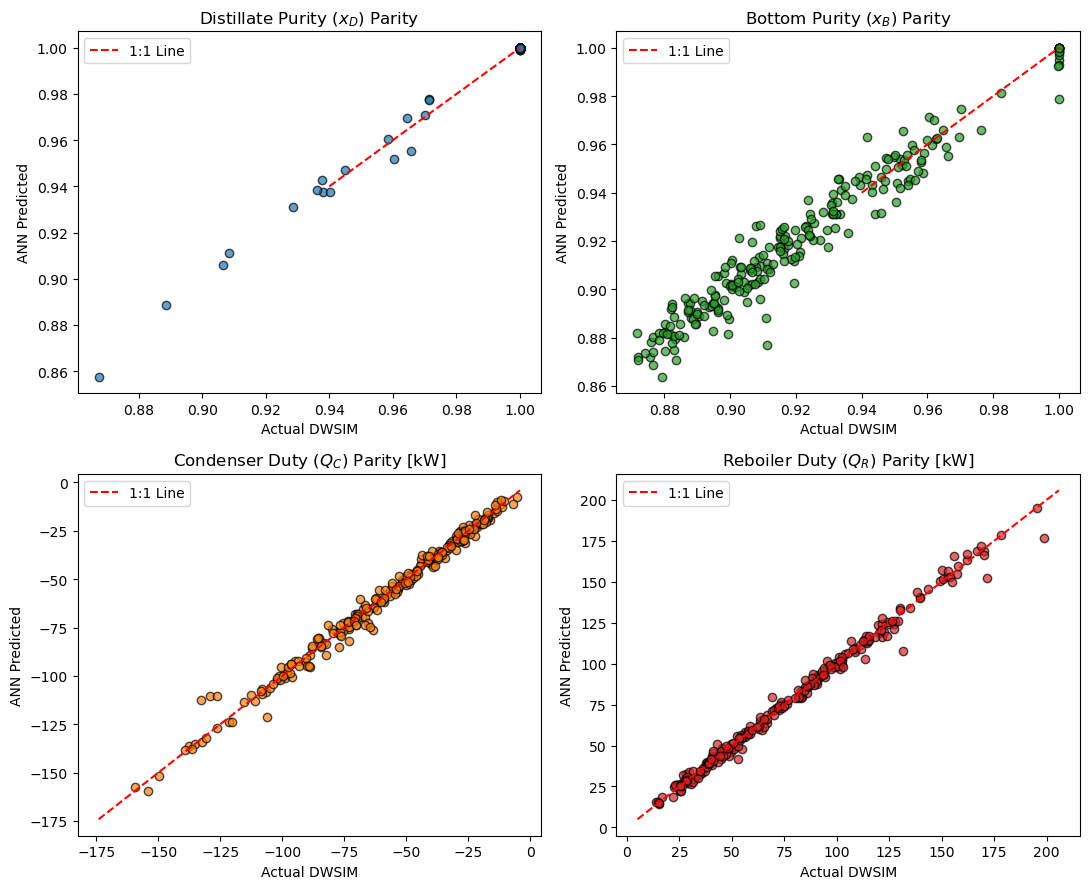

In [2]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
# 1. Distillate Purity Parity
axes[0, 0].scatter(y_dist.iloc[test_idx], pred_ann_dist, color='#1f77b4', alpha=0.7, edgecolors='k')
axes[0, 0].plot([0.94, 1.0], [0.94, 1.0], 'r--', label='1:1 Line')
axes[0, 0].set_title('Distillate Purity ($x_D$) Parity')
axes[0, 0].set_xlabel('Actual DWSIM'); axes[0, 0].set_ylabel('ANN Predicted'); axes[0, 0].legend()
# 2. Bottom Purity Parity
axes[0, 1].scatter(y_btm.iloc[test_idx], pred_ann_btm, color='#2ca02c', alpha=0.7, edgecolors='k')
axes[0, 1].plot([0.94, 1.0], [0.94, 1.0], 'r--', label='1:1 Line')
axes[0, 1].set_title('Bottom Purity ($x_B$) Parity')
axes[0, 1].set_xlabel('Actual DWSIM'); axes[0, 1].set_ylabel('ANN Predicted'); axes[0, 1].legend()
# 3. Condenser Duty Parity
axes[1, 0].scatter(y_cond.iloc[test_idx], pred_ann_cond, color='#ff7f0e', alpha=0.7, edgecolors='k')
axes[1, 0].plot([y_cond.min(), y_cond.max()], [y_cond.min(), y_cond.max()], 'r--', label='1:1 Line')
axes[1, 0].set_title('Condenser Duty ($Q_C$) Parity [kW]')
axes[1, 0].set_xlabel('Actual DWSIM'); axes[1, 0].set_ylabel('ANN Predicted'); axes[1, 0].legend()
# 4. Reboiler Duty Parity
axes[1, 1].scatter(y_reb.iloc[test_idx], pred_ann_reb, color='#d62728', alpha=0.7, edgecolors='k')
axes[1, 1].plot([y_reb.min(), y_reb.max()], [y_reb.min(), y_reb.max()], 'r--', label='1:1 Line')
axes[1, 1].set_title('Reboiler Duty ($Q_R$) Parity [kW]')
axes[1, 1].set_xlabel('Actual DWSIM'); axes[1, 1].set_ylabel('ANN Predicted'); axes[1, 1].legend()
plt.tight_layout()
plt.savefig("plot1_parity.png", dpi=300)
plt.show()

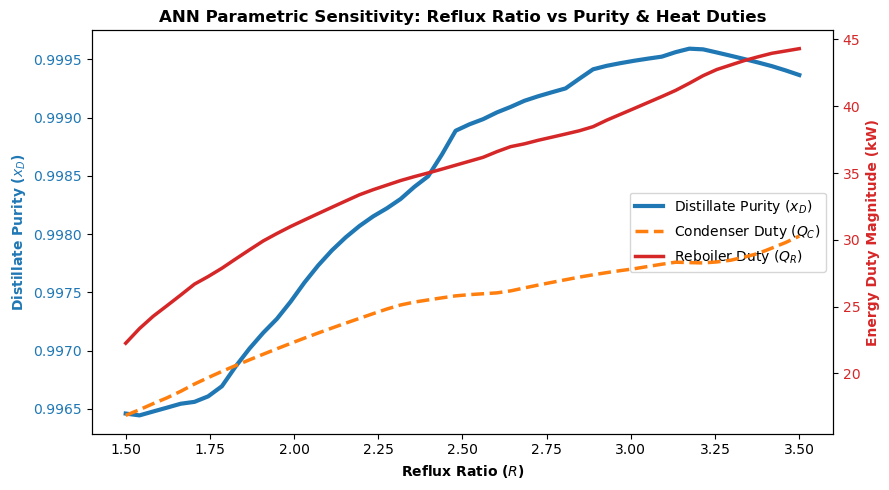

In [5]:
reflux_sweep = np.linspace(1.5, 3.5, 50)  # Clean range from 1.5 to 3.5
sweep_base = {
    "Feed temperature": 350.0,
    "Feed pressure": 1.2,
    "Feed composition": 0.5,
    "Number of stages": 25, 
    "Reflux ratio": 2.0, 
    "Bottoms withdrawal rate": 1.0,
    "Molar flow": 2.0, 
    "Column pressure": 1.013,
    "Feed Stage": 12
}
sweep_rows = [dict(sweep_base, **{"Reflux ratio": r}) for r in reflux_sweep]
df_sweep = pd.DataFrame(sweep_rows)
X_sweep_raw = engineer_features(df_sweep)
X_sweep_scaled = scaler_x.transform(X_sweep_raw)
# Take absolute magnitude for Condenser Duty so both duties plot as positive kW
sweep_pred_dist = np.clip(ann_dist.predict(X_sweep_scaled), 0.0, 1.0)
sweep_pred_cond = np.abs(ann_cond.predict(X_sweep_scaled))   # Magnitude (Positive kW)
sweep_pred_reb  = ann_reb.predict(X_sweep_scaled)
fig, ax1 = plt.subplots(figsize=(9, 5))
color = '#1f77b4'
ax1.set_xlabel('Reflux Ratio ($R$)', fontweight='bold')
ax1.set_ylabel('Distillate Purity ($x_D$)', color=color, fontweight='bold')
line1 = ax1.plot(reflux_sweep, sweep_pred_dist, color=color, lw=3, label='Distillate Purity ($x_D$)')
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Energy Duty Magnitude (kW)', color=color, fontweight='bold')
line2 = ax2.plot(reflux_sweep, sweep_pred_cond, color='#ff7f0e', lw=2.5, linestyle='--', label='Condenser Duty ($Q_C$)')
line3 = ax2.plot(reflux_sweep, sweep_pred_reb, color='#d62728', lw=2.5, linestyle='-', label='Reboiler Duty ($Q_R$)')
ax2.tick_params(axis='y', labelcolor=color)
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True)
plt.title('ANN Parametric Sensitivity: Reflux Ratio vs Purity & Heat Duties', fontweight='bold')
plt.tight_layout()
plt.savefig("ann_parametric_trends_clean.png", dpi=300)
plt.show()